# Signal Transformations (Discrete)

In [1]:
from pathlib import Path
import sys, csv

COURSEUTILS_DIR = Path.home() / "Documents/GitHub/Signals_and_Systems/courseutils"
sys.path.insert(0, str(COURSEUTILS_DIR))

import basic_material as bm
bm.setup_environment()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sympy import oo, Symbol, integrate, exp, Heaviside, plot, sin, cos, Piecewise, printing, lambdify
from sympy.abc import t, x
from sympy.interactive import init_printing
init_printing(pretty_print=True)

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## Motivation

**Goal:** analyze the impact of a transformation of the form $e[k] \to e[a k + b]$ on a signal (discrete) for various positive/negative $a$ and $b$

* $a$ acts as a **scaling on time** ($a > 1$ shrinks the signal plot). Note that negative $a$ leads to a time reversal.
* $b$ acts as **shift on time** ($b > 0$ shifts to the left) 

Relatively straight forward when only one of $a$ or $b$ are present, but some care required when both appear.

Systematic approach is to consider these as compositions of functions

In [3]:
#   Simple hand coded example      
data = ([-3,-2,-1,0,1,2,3,4,5],[0.5,1,-1.5,0.5,1,-1,0,1.5,-1])

# creates the transformed signal; skips samples whose transformed index is not in the original data
def sample_transform(k, a=1, b=0, verbose=False):
    f1_vals = []
    nlist = []
    skipped = []

    original_indices = list(data[0])

    for ii in k:
        transformed_index = a*ii + b

        try:
            idx = original_indices.index(transformed_index)
            f1_vals.append(data[1][idx])
            nlist.append(ii)
        except ValueError:
            skipped.append(ii)

    if verbose and skipped:
        print("Skipped k values:", skipped)

    return f1_vals, nlist


## Transformation Approach

For the transformed signal

$$
y[k] = e[ak+b],
$$

each output sample is found by asking which input sample index is requested:

$$
m = ak+b.
$$

If $m$ is an integer index where $e[m]$ is defined, then

$$
y[k] = e[m].
$$

If $m$ is not an available input index, then the output sample at that $k$ is left blank.

For visualization, it is useful to split the transformation into two steps:

$$
f[k] = e[k+b]
$$

followed by

$$
y[k] = f[ak].
$$

So the intermediate plot is the shifted signal $f[k]=e[k+b]$, and the final plot is obtained by sampling that intermediate signal at the indices $ak$.

In [4]:
# transform parameters t -> a*t+b
a = 2
b = 0

# plotting range
k = np.arange(-6,11)

# original signal
F1, k1 = sample_transform(k)
F2, k2 = sample_transform(k, a, b, verbose=True)
F3, k3 = sample_transform(k, 1/a, b)

Skipped k values: [-6, -5, -4, -3, -2, 3, 4, 5, 6, 7, 8, 9, 10]


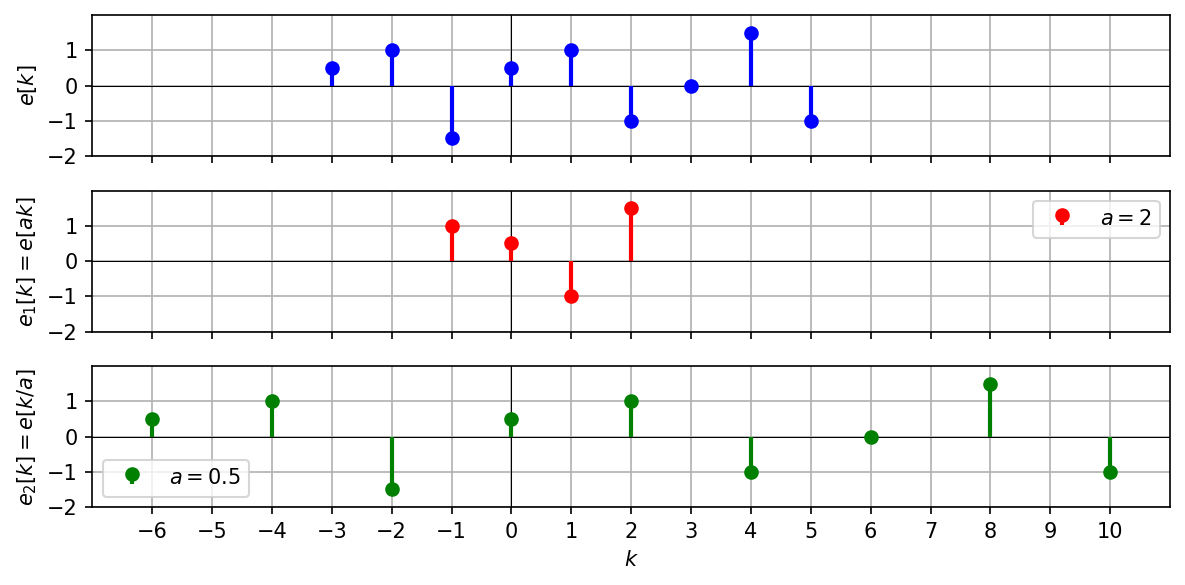

In [5]:
fig = plt.figure(figsize=(8, 4),dpi=150)
ax1 = fig.add_subplot(311)
ax1.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax1.plot([0,0],[-2, 2],'k-',lw=0.5)
ax2 = fig.add_subplot(312, sharex=ax1, sharey=ax1)
ax2.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax2.plot([0,0],[-2, 2],'k-',lw=0.5)
ax3 = fig.add_subplot(313, sharex=ax1, sharey=ax1)
ax3.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax3.plot([0,0],[-2, 2],'k-',lw=0.5)

major_ticks = k    
ax1.set_xticks(major_ticks)
ax1.set_yticks(np.arange(-2,2))
ax1.grid(True)

markerline, stemlines, baseline = ax1.stem(k1, F1,linefmt='b',markerfmt='bo')
plt.setp(baseline, visible=False)
markerline, stemlines, baseline = ax2.stem(k2, F2,linefmt='r',markerfmt='ro',label='$a = $'+str(a))
plt.setp(baseline, visible=False)
ax2.legend()
markerline, stemlines, baseline = ax3.stem(k3, F3,linefmt='g',markerfmt='go',label='$a = $'+str(1/a))
plt.setp(baseline, visible=False)
ax3.legend()

ax1.set_xlim([k[0]-1, k[-1]+1])
ax1.set_ylim([-2, 2])
ax1.set_ylabel('$e[k]$')
ax2.set_ylabel('$e_1[k]=e[ak]$')
ax3.set_ylabel('$e_2[k]=e[k/a]$')
ax3.set_xlabel('$k$')

plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.show()

* In discrete time, $ak+b$ must be one of the integer indices where $e[k]$ is defined.

* If $ak+b$ is non-integer, or if it lies outside the available data, that output sample is left blank.

* For example, note that $e_2[k]=0$ for $k=6$ because $e[3]=0$, but the dilated response at $e_2[k]$ for $k=-5,-3,-1,1,3,5,7,9$ does not exist and is left blank.

## Consider case with $k \to 1-2k$

In [6]:
# transform parameters t -> a*t+b
a = -2
b = 1

# original signal
F1, k1 = sample_transform(k) # e[k]
F2, k2 = sample_transform(k, 1, b) # e[k+b]
F3, k3 = sample_transform(k, a, b) # e[ak+b]


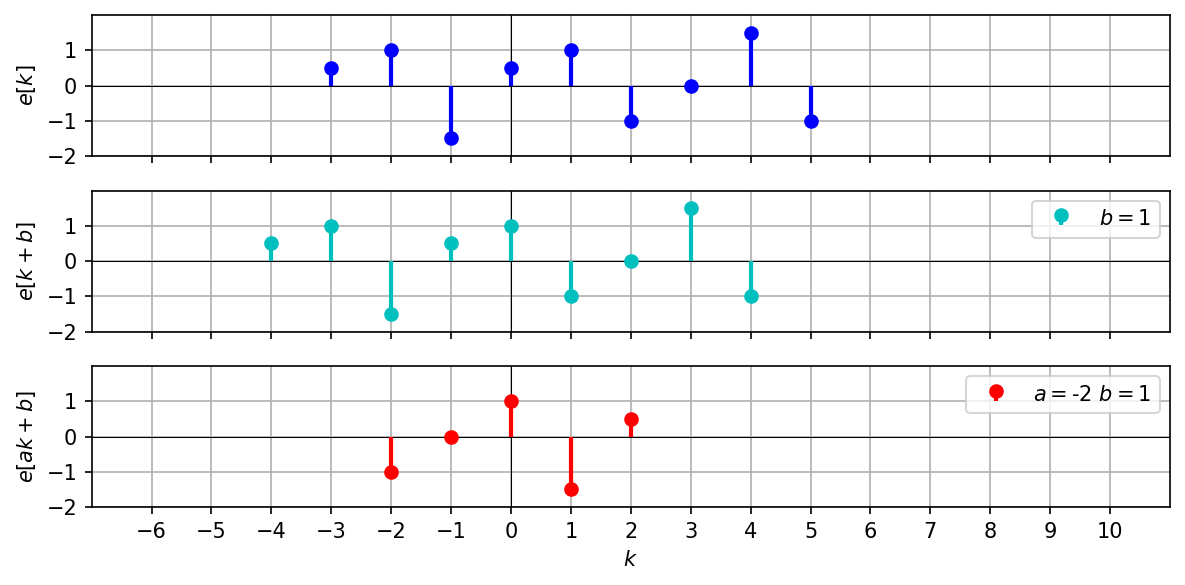

In [7]:

fig = plt.figure(figsize=(8, 4),dpi=150)
ax1 = fig.add_subplot(311)
ax1.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax1.plot([0,0],[-2, 2],'k-',lw=0.5)
ax2 = fig.add_subplot(312, sharex=ax1, sharey=ax1)
ax2.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax2.plot([0,0],[-2, 2],'k-',lw=0.5)
ax3 = fig.add_subplot(313, sharex=ax1, sharey=ax1)
ax3.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax3.plot([0,0],[-2, 2],'k-',lw=0.5)

major_ticks = k    
ax1.set_xticks(major_ticks)
ax1.set_yticks(np.arange(-2,2))
ax1.grid(True)

markerline, stemlines, baseline = ax1.stem(k1, F1,linefmt='b',markerfmt='bo')
plt.setp(baseline, visible=False)
markerline, stemlines, baseline = ax2.stem(k2, F2,linefmt='c',markerfmt='co',label='$b = $'+str(b))
plt.setp(baseline, visible=False)
ax2.legend()
markerline, stemlines, baseline = ax3.stem(k3, F3,linefmt='r',markerfmt='ro',label='$a = $'+str(a)+' $b = $'+str(b))
plt.setp(baseline, visible=False)
ax3.legend()

ax1.set_xlim([k[0]-1, k[-1]+1])
ax1.set_ylim([-2, 2])
ax1.set_ylabel('$e[k]$')
ax2.set_ylabel('$e[k+b]$')
ax3.set_ylabel('$e[ak+b]$')
ax3.set_xlabel('$k$')

plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.show()

* Cyan plot shows the intermediate step (after shifting by $b=1$) 
* The cyan zero value at $k=2$ is then mapped to the red zero at $k=-1$ in the final result. 
* Since $a$ is even, all cyan values for odd $k$ are removed by the compression.